In [ ]:
import numpy as np
import pickle

# Load data
with open('/content/drive/MyDrive/data-Physionet/train_dataset.pkl', 'rb') as f:
    d = pickle.load(f)
    X_train, y_train = d['X_train'], d['y_train']

with open('/content/drive/MyDrive/data-Physionet/test_dataset.pkl', 'rb') as f:
    d = pickle.load(f)
    X_test, y_test = d['X_test'], d['y_test']

# Labels
labels = {'Normal': 0, 'Hemorrhage': 1}
# Create a reverse mapping for printing
idx_to_label = {value: key for key, value in labels.items()}

# Split data training / validation

from sklearn.model_selection import train_test_split

# 2. Take 25% of the remaining training pool for Validation (25% of 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribuição de classes no conjunto de treino:")
unique, counts = np.unique(y_train, return_counts=True)
for i in range(len(unique)):
    print(f"{idx_to_label[unique[i]]}: {counts[i]}")

print("\nDistribuição de classes no conjunto de validação:")
unique, counts = np.unique(y_val, return_counts=True)
for i in range(len(unique)):
    print(f"{idx_to_label[unique[i]]}: {counts[i]}")

print("\nDistribuição de classes no conjunto de teste:")
unique, counts = np.unique(y_test, return_counts=True)
for i in range(len(unique)):
    print(f"{idx_to_label[unique[i]]}: {counts[i]}")

X_train shape: (1684, 256, 256)
y_train shape: (1684,)
X_test shape: (568, 256, 256)
y_test shape: (568,)

Distribuição de classes no conjunto de treino:
Normal: 1499
Hemorrhage: 185

Distribuição de classes no conjunto de validação:
Normal: 500
Hemorrhage: 62

Distribuição de classes no conjunto de teste:
Normal: 497
Hemorrhage: 71


In [ ]:
# =========================================================================================
# CNN 2D Classifier — VGG-16 adaptada para binário, 256x256, 1 canal
# =========================================================================================
import os, random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------------------------------------------------------------------
# Configuração
# -----------------------------------------------------------------------------------------
IMG_SIZE      = (256, 256)
INPUT_SHAPE   = (*IMG_SIZE, 1)     # (256, 256, 1)
LEARNING_RATE = 1e-4
BATCH_SIZE    = 8
EPOCHS        = 100

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------------------------------------------------------------------
# Definição do modelo
# -----------------------------------------------------------------------------------------
def vgg16_binaria(input_shape=(256, 256, 1)):
    inputs = Input(shape=input_shape)

    # Normalização dos pixels [0, 255] -> [0, 1] dentro do modelo
    x = layers.Rescaling(1./255, name='normalizacao')(inputs)

    # Bloco 1
    x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False, name='block1_conv1')(x)
    x = layers.BatchNormalization(name='block1_bn1')(x)
    x = layers.Activation('relu', name='block1_relu1')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False, name='block1_conv2')(x)
    x = layers.BatchNormalization(name='block1_bn2')(x)
    x = layers.Activation('relu', name='block1_relu2')(x)
    x = layers.MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool')(x)  # 128x128

    # Bloco 2
    x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False, name='block2_conv1')(x)
    x = layers.BatchNormalization(name='block2_bn1')(x)
    x = layers.Activation('relu', name='block2_relu1')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False, name='block2_conv2')(x)
    x = layers.BatchNormalization(name='block2_bn2')(x)
    x = layers.Activation('relu', name='block2_relu2')(x)
    x = layers.MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool')(x)  # 64x64

    # Bloco 3
    x = layers.Conv2D(256, (3, 3), padding='same', use_bias=False, name='block3_conv1')(x)
    x = layers.BatchNormalization(name='block3_bn1')(x)
    x = layers.Activation('relu', name='block3_relu1')(x)
    x = layers.Conv2D(256, (3, 3), padding='same', use_bias=False, name='block3_conv2')(x)
    x = layers.BatchNormalization(name='block3_bn2')(x)
    x = layers.Activation('relu', name='block3_relu2')(x)
    x = layers.Conv2D(256, (3, 3), padding='same', use_bias=False, name='block3_conv3')(x)
    x = layers.BatchNormalization(name='block3_bn3')(x)
    x = layers.Activation('relu', name='block3_relu3')(x)
    x = layers.MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool')(x)  # 32x32

    # Bloco 4
    x = layers.Conv2D(512, (3, 3), padding='same', use_bias=False, name='block4_conv1')(x)
    x = layers.BatchNormalization(name='block4_bn1')(x)
    x = layers.Activation('relu', name='block4_relu1')(x)
    x = layers.Conv2D(512, (3, 3), padding='same', use_bias=False, name='block4_conv2')(x)
    x = layers.BatchNormalization(name='block4_bn2')(x)
    x = layers.Activation('relu', name='block4_relu2')(x)
    x = layers.Conv2D(512, (3, 3), padding='same', use_bias=False, name='block4_conv3')(x)
    x = layers.BatchNormalization(name='block4_bn3')(x)
    x = layers.Activation('relu', name='block4_relu3')(x)
    x = layers.MaxPooling2D((2, 2), strides=(2, 2), name='block4_pool')(x)  # 16x16

    # Bloco 5
    x = layers.Conv2D(512, (3, 3), padding='same', use_bias=False, name='block5_conv1')(x)
    x = layers.BatchNormalization(name='block5_bn1')(x)
    x = layers.Activation('relu', name='block5_relu1')(x)
    x = layers.Conv2D(512, (3, 3), padding='same', use_bias=False, name='block5_conv2')(x)
    x = layers.BatchNormalization(name='block5_bn2')(x)
    x = layers.Activation('relu', name='block5_relu2')(x)
    x = layers.Conv2D(512, (3, 3), padding='same', use_bias=False, name='block5_conv3')(x)
    x = layers.BatchNormalization(name='block5_bn3')(x)
    x = layers.Activation('relu', name='block5_relu3')(x)
    x = layers.MaxPooling2D((2, 2), strides=(2, 2), name='block5_pool')(x)  # 8x8

    # Classificador
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(512, name='fc1')(x)
    x = layers.BatchNormalization(name='fc1_bn')(x)
    x = layers.Activation('relu', name='fc1_relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, name='fc2')(x)
    x = layers.BatchNormalization(name='fc2_bn')(x)
    x = layers.Activation('relu', name='fc2_relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid', name='predictions')(x)

    return models.Model(inputs, outputs, name='vgg16_binaria')

model = vgg16_binaria(input_shape=INPUT_SHAPE)
model.summary()

# -----------------------------------------------------------------------------------------
# Compilação
# -----------------------------------------------------------------------------------------
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

# -----------------------------------------------------------------------------------------
# Callbacks
# -----------------------------------------------------------------------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', mode='min', patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', mode='min', factor=0.2, patience=5, min_lr=1e-7)
]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: float(class_weights[0]), 1: float(class_weights[1])}
print("Class weights:", class_weight_dict)

Model: "vgg16_binaria"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalizacao (Rescaling)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 256, 256, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 256, 256, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 128, 128, 128)  │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 128, 128, 128)  │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 64, 64, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 64, 64, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn3 (BatchNormalization) │ (None, 64, 64, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu3 (Activation)       │ (None, 64, 64, 256)    │             

 Total params: 15,123,521 (57.69 MB)

 Trainable params: 15,113,537 (57.65 MB)

 Non-trainable params: 9,984 (39.00 KB)

Class weights: {0: 0.561707805203469, 1: 4.551351351351351}


In [ ]:
import time
# Treino

start_time = time.time()

history = model.fit(
    X_train, y_train,
    shuffle=True,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)
end_time = time.time()

training_time = end_time - start_time

print("\nTraining completed.")
print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time / 60:.2f} minutes")

Epoch 1/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 45s 110ms/step - accuracy: 0.6306 - auc: 0.7942 - loss: 0.5670 - precision: 0.2027 - recall: 0.8054 - val_accuracy: 0.8897 - val_auc: 0.6566 - val_loss: 0.3395 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7328 - auc: 0.8627 - loss: 0.4746 - precision: 0.2750 - recall: 0.8757 - val_accuracy: 0.1103 - val_auc: 0.5630 - val_loss: 7.1300 - val_precision: 0.1103 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7690 - auc: 0.8759 - loss: 0.4443 - precision: 0.3016 - recall: 0.8378 - val_accuracy: 0.2438 - val_auc: 0.8240 - val_loss: 2.4110 - val_precision: 0.1273 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7910 - auc: 0.9029 - loss: 0.3944 - precision: 0.3285 - recall: 0.8649 - val_accuracy: 0.4057 - val_auc: 0

In [ ]:
# Evaluate the model on the test set
print("Evaluating on test set...")
test_loss, test_accuracy, test_precision, test_recall, test_auc = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Loss: {test_loss:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")
print(f"Test Precision: {test_precision:.3f}")
print(f"Test Recall: {test_recall:.3f}")
print(f"Test AUC: {test_auc:.3f}")

Evaluating on test set...
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 474ms/step - accuracy: 0.8820 - auc: 0.8616 - loss: 0.3904 - precision: 0.5238 - recall: 0.6197

Test Loss: 0.390
Test Accuracy: 0.882
Test Precision: 0.524
Test Recall: 0.620
Test AUC: 0.862


In [ ]:
# Classification report
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int).ravel()
y_true = y_test

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=list(labels.keys())))

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.92      0.93       497
  Hemorrhage       0.52      0.62      0.57        71

    accuracy                           0.88       568
   macro avg       0.73      0.77      0.75       568
weighted avg       0.89      0.88      0.89       568



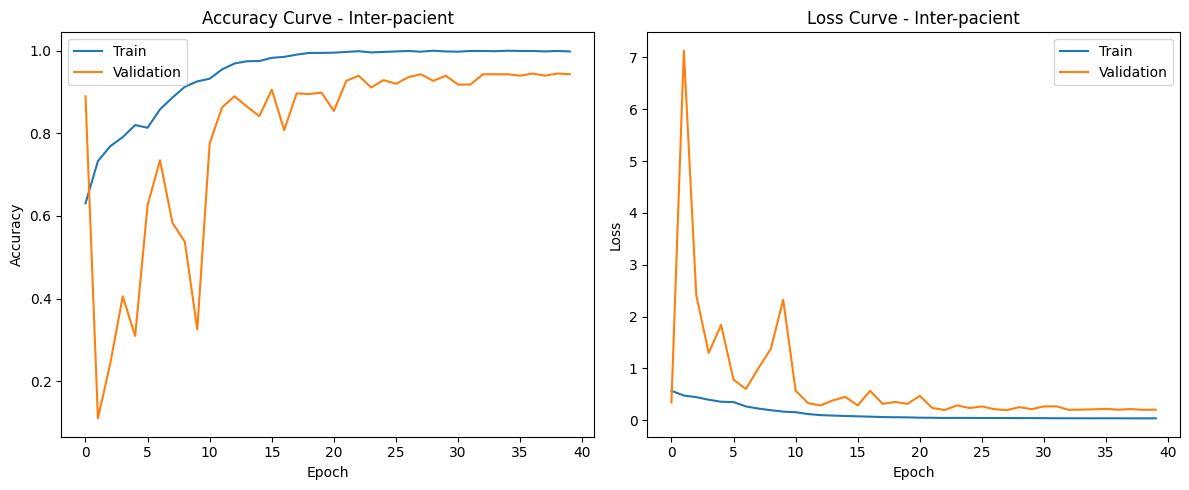

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy Curve - Inter-pacient')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss Curve - Inter-pacient')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()
plt.show()

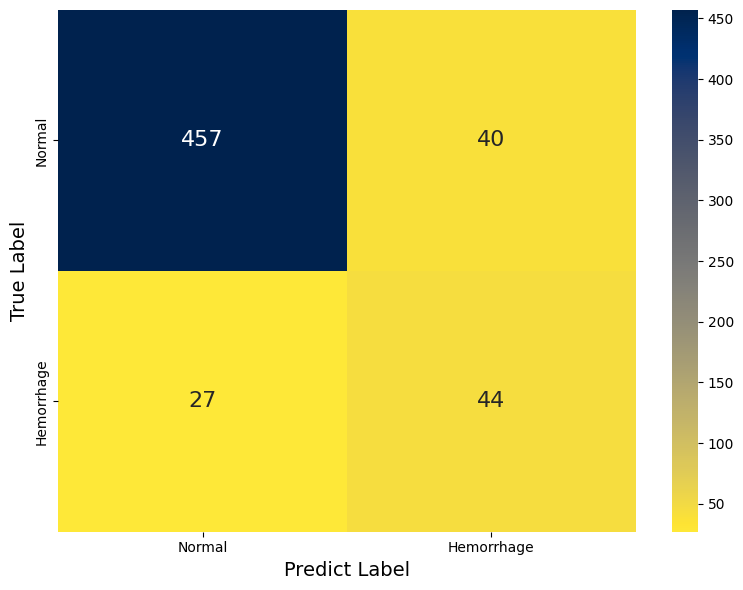

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve

y_pred_classes = (y_pred > 0.5).astype(int).flatten()

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_classes)

# Plotar
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='cividis_r', cbar=True,
            xticklabels=labels, yticklabels=labels, annot_kws={"size": 16})
# plt.xticks(rotation=45)
plt.xlabel('Predict Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tight_layout()
plt.show()

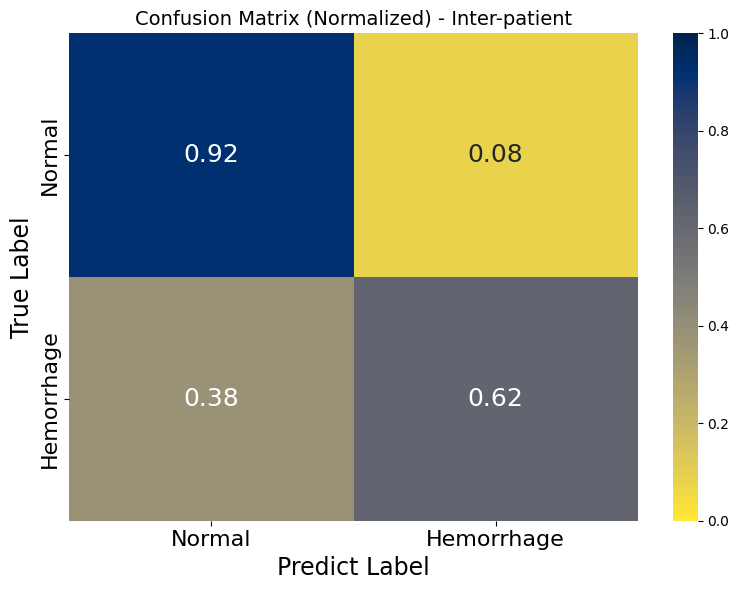

In [ ]:
# Matriz de porcentagens -- NORMALIZAÇÃO POR LINHA (SENSIBILIDADE E ESPECIFICIDADE NA DIAGONAL PRINCIPAL)
plt.figure(figsize=(8, 6))
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Normalização por COLUNA (mostra precision)
# cm_percent_col = cm.astype('float') / cm.sum(axis=0)[np.newaxis, :]

sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='cividis_r', cbar=True,  # .2% mostra como %
            xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 18}, vmin=0, vmax=1)  # Escala fixa 0-100%
# plt.xticks(rotation=45)
plt.xlabel('Predict Label', fontsize=17)
plt.ylabel('True Label', fontsize=17)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title('Confusion Matrix (Normalized) - Inter-patient', fontsize=14)
plt.tight_layout()
plt.show()

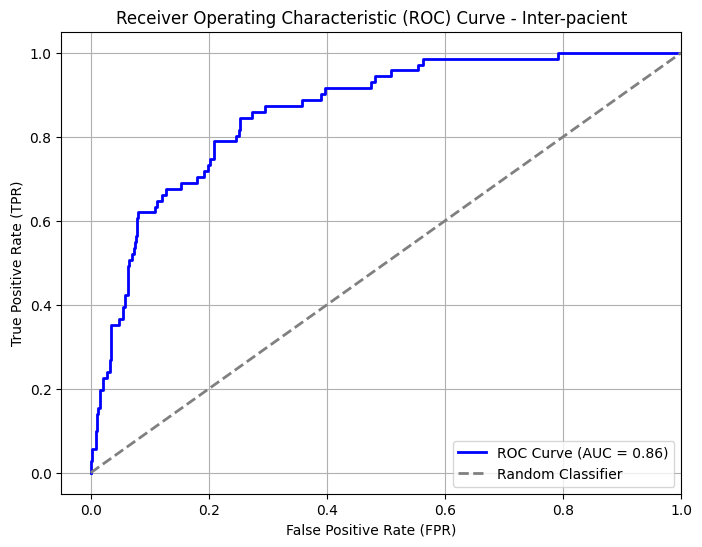

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([-0.05, 1.0])
plt.ylim([-0.05, 1.05])
plt.title('Receiver Operating Characteristic (ROC) Curve - Inter-pacient')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()